# Ensemble Learning: Bagging Classifier on the Iris Dataset

---

## Introduction

**Bagging** (Bootstrap Aggregating) is a parallel ensemble method designed to reduce the variance of high-variance base learners. Each base model is trained on a different **bootstrap sample** — a random sample drawn *with replacement* from the training data. For classification tasks, predictions from all base learners are combined through **majority voting**.

This notebook builds a bagging classifier **from scratch** using the Iris dataset, manually demonstrating the core mechanics of the algorithm:

1. Draw bootstrap samples from the training data (with replacement)
2. Train an independent `DecisionTreeClassifier` on each sample
3. Aggregate predictions via majority vote at inference time

Unlike the previous notebook which used scikit-learn's `BaggingRegressor`, this notebook makes the internals of the algorithm explicit — each bootstrap sample, each decision tree, and each prediction are handled step by step.

### Dataset

The **Iris dataset** contains 150 samples across three species of iris flowers. For this binary classification experiment, we filter to two classes — *Iris-versicolor* (1) and *Iris-virginica* (2) — using only **SepalWidthCm** and **PetalLengthCm** as features, enabling 2D decision boundary visualization.

---

## 1. Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import LabelEncoder
from mlxtend.plotting import plot_decision_regions

import warnings
warnings.filterwarnings('ignore')

---

## 2. Loading and Preparing the Dataset

In [3]:
df = pd.read_csv('Iris.csv')
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### 2.1 Label Encoding

The `Species` column is encoded as integers:
- `Iris-setosa`     → 0
- `Iris-versicolor` → 1
- `Iris-virginica`  → 2

In [4]:
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

print("Class distribution:")
print(df['Species'].value_counts().sort_index())

Class distribution:
Species
0    50
1    50
2    50
Name: count, dtype: int64


### 2.2 Filtering to a Binary Classification Problem

We drop *Iris-setosa* (class 0) and keep only two classes (1 and 2), which are harder to separate and make for a more interesting classification boundary. We also reduce to two features to allow 2D visualization.

In [5]:
df = df[df['Species'] != 0][['SepalWidthCm', 'PetalLengthCm', 'Species']]

print("Filtered dataset shape:", df.shape)
df.head()

Filtered dataset shape: (100, 3)


,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


### 2.3 Feature Space Visualization

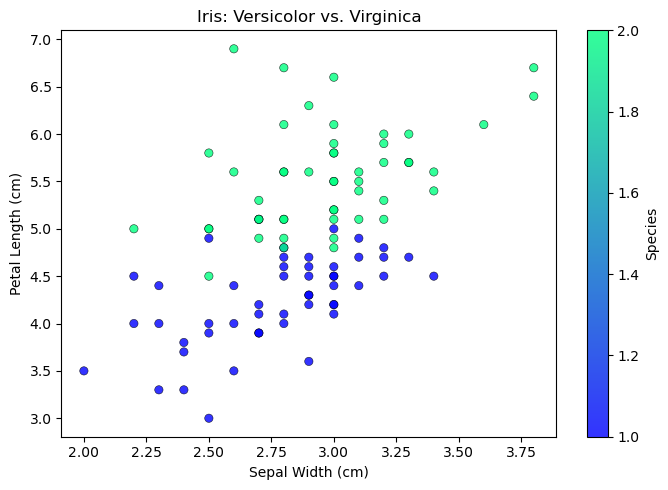

In [6]:
plt.figure(figsize=(7, 5))
plt.scatter(df['SepalWidthCm'], df['PetalLengthCm'], c=df['Species'], cmap='winter',
            edgecolors='k', linewidths=0.4, alpha=0.8)
plt.xlabel('Sepal Width (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Iris: Versicolor vs. Virginica')
plt.colorbar(label='Species')
plt.tight_layout()
plt.show()

---

## 3. Train / Validation / Test Split

The dataset is shuffled, then split into three non-overlapping partitions:

| Split | Rows | Samples | Purpose |
|---|---|---|---|
| Train pool | 0–59 | 10 (bootstrap) | Bootstrap sampling source |
| Validation | 60–79 | 5 | Accuracy evaluation during training |
| Test | 80–99 | 5 | Final held-out inference demo |

In [7]:
# Shuffle the entire dataset
df = df.sample(100, random_state=42).reset_index(drop=True)

# Split into train pool, validation, and test sets
df_train = df.iloc[:60, :].sample(10, random_state=42)
df_val   = df.iloc[60:80, :].sample(5, random_state=42)
df_test  = df.iloc[80:, :].sample(5, random_state=42)

# Extract validation features and labels for evaluation
X_val = df_val.iloc[:, 0:2].values
y_val = df_val.iloc[:, -1].values

print("Train pool shape :", df_train.shape)
print("Validation shape :", df_val.shape)
print("Test shape       :", df_test.shape)

Train pool shape : (10, 3)
Validation shape : (5, 3)
Test shape       : (5, 3)


---

## 4. Helper: Evaluate Function

The `evaluate` function fits a classifier on the provided data, visualizes the learned decision tree structure and the resulting decision boundary, then prints accuracy on the validation set.

In [8]:
def evaluate(clf, X, y, title="Decision Tree"):
    """Fit classifier, plot tree + decision boundary, print validation accuracy."""
    clf.fit(X, y)

    # Plot decision tree structure
    plt.figure(figsize=(10, 4))
    plot_tree(clf, feature_names=['SepalWidthCm', 'PetalLengthCm'],
              class_names=['Versicolor', 'Virginica'], filled=True)
    plt.title(f"{title} — Tree Structure")
    plt.tight_layout()
    plt.show()

    # Plot decision boundary
    plt.figure(figsize=(7, 5))
    plot_decision_regions(X.values, y.values, clf=clf, legend=2)
    plt.xlabel('Sepal Width (cm)')
    plt.ylabel('Petal Length (cm)')
    plt.title(f"{title} — Decision Boundary")
    plt.tight_layout()
    plt.show()

    # Validation accuracy
    y_pred = clf.predict(X_val)
    acc = accuracy_score(y_val, y_pred)
    print(f"{title}  —  Validation Accuracy: {acc:.2f}")

---

## 5. Manual Bagging: Three Bootstrap Trees

We manually implement three rounds of bagging. In each round:
1. A bootstrap sample of 8 rows is drawn **with replacement** from the 10-sample training pool
2. A `DecisionTreeClassifier` is trained on that sample
3. The tree structure and decision boundary are visualized

Because each tree trains on a different random subset of data, they will each produce slightly different decision boundaries — this diversity is the foundation of bagging's variance reduction.

### 5.1 Tree 1

In [9]:
# Bootstrap sample for Tree 1
df_bag1 = df_train.sample(8, replace=True, random_state=1)
X1 = df_bag1.iloc[:, 0:2]
y1 = df_bag1.iloc[:, -1]

print("Bootstrap sample (Tree 1):")
print(df_bag1)

Bootstrap sample (Tree 1):
    SepalWidthCm  PetalLengthCm  Species
54           2.9            4.6        1
12           2.7            4.9        2
57           2.8            5.1        2
54           2.9            4.6        1
0            2.8            5.1        2
0            2.8            5.1        2
5            2.5            4.0        1
48           3.0            5.5        2


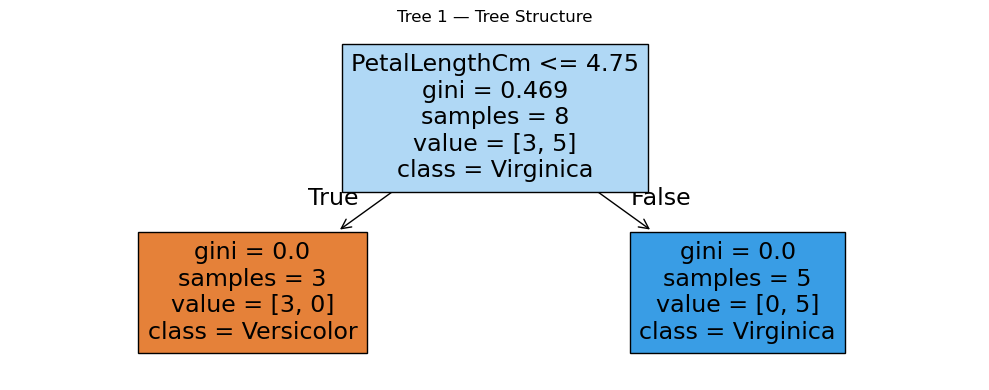

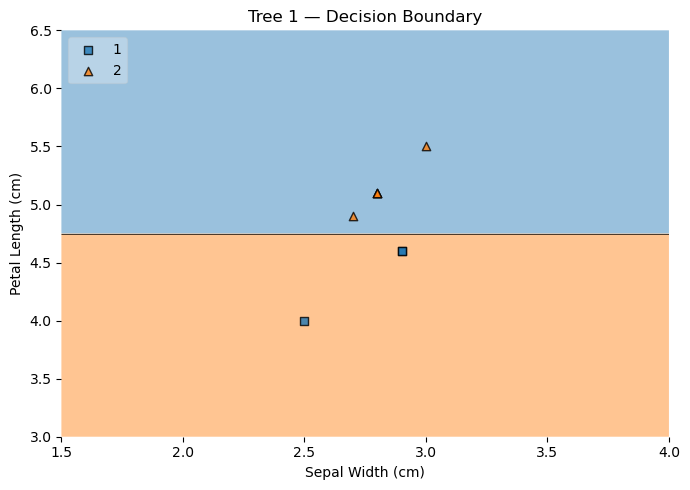

Tree 1  —  Validation Accuracy: 0.80


In [10]:
clf1 = DecisionTreeClassifier(random_state=1)
evaluate(clf1, X1, y1, title="Tree 1")

### 5.2 Tree 2

In [11]:
# Bootstrap sample for Tree 2
df_bag2 = df_train.sample(8, replace=True, random_state=2)
X2 = df_bag2.iloc[:, 0:2]
y2 = df_bag2.iloc[:, -1]

print("Bootstrap sample (Tree 2):")
print(df_bag2)

Bootstrap sample (Tree 2):
    SepalWidthCm  PetalLengthCm  Species
12           2.7            4.9        2
12           2.7            4.9        2
33           2.9            4.5        1
36           3.0            5.5        2
12           2.7            4.9        2
48           3.0            5.5        2
36           3.0            5.5        2
5            2.5            4.0        1


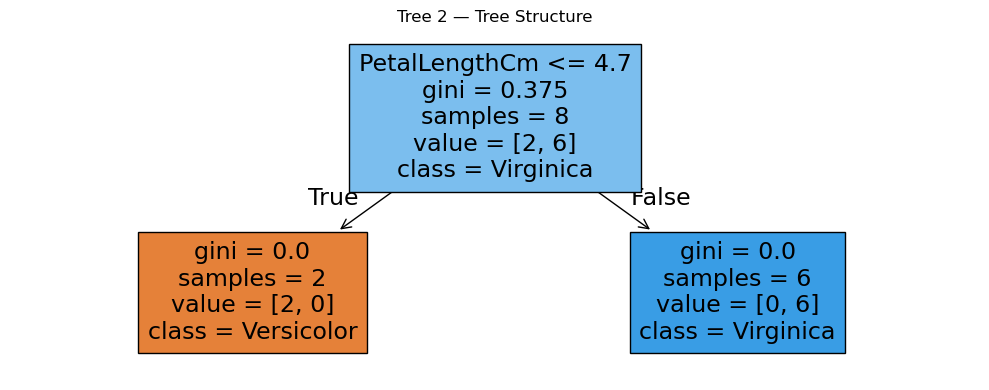

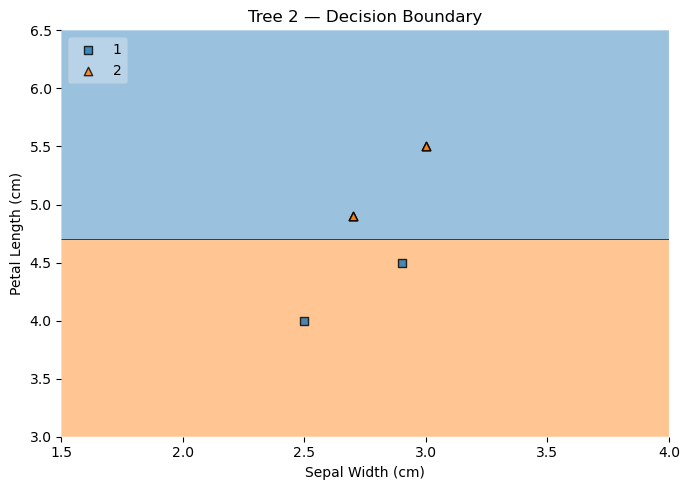

Tree 2  —  Validation Accuracy: 0.80


In [12]:
clf2 = DecisionTreeClassifier(random_state=2)
evaluate(clf2, X2, y2, title="Tree 2")

### 5.3 Tree 3

In [13]:
# Bootstrap sample for Tree 3
df_bag3 = df_train.sample(8, replace=True, random_state=3)
X3 = df_bag3.iloc[:, 0:2]
y3 = df_bag3.iloc[:, -1]

print("Bootstrap sample (Tree 3):")
print(df_bag3)

Bootstrap sample (Tree 3):
    SepalWidthCm  PetalLengthCm  Species
12           2.7            4.9        2
57           2.8            5.1        2
45           2.5            3.9        1
12           2.7            4.9        2
12           2.7            4.9        2
0            2.8            5.1        2
54           2.9            4.6        1
45           2.5            3.9        1


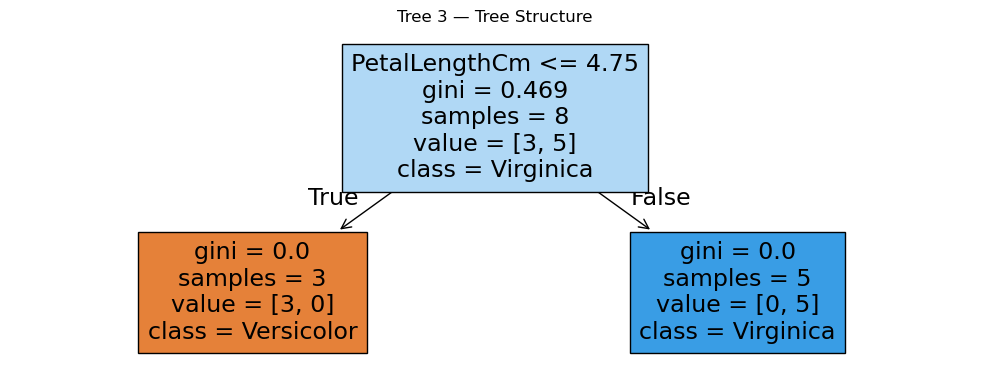

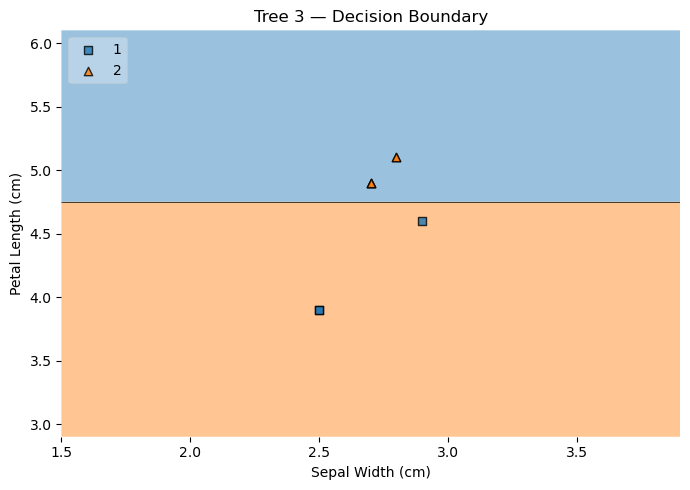

Tree 3  —  Validation Accuracy: 0.80


In [14]:
clf3 = DecisionTreeClassifier(random_state=3)
evaluate(clf3, X3, y3, title="Tree 3")

---

## 6. Majority Vote Prediction

Given a new sample, all three trees cast a vote. The class with the most votes wins. Here we demonstrate inference on a single sample: `[SepalWidthCm=3.1, PetalLengthCm=5.5]`.

In [15]:
sample = np.array([3.1, 5.5]).reshape(1, 2)

p1 = clf1.predict(sample)[0]
p2 = clf2.predict(sample)[0]
p3 = clf3.predict(sample)[0]

votes = [p1, p2, p3]
final_pred = max(set(votes), key=votes.count)

print(f"Sample: SepalWidthCm=3.1, PetalLengthCm=5.5")
print(f"-" * 40)
print(f"Tree 1 prediction : {p1}")
print(f"Tree 2 prediction : {p2}")
print(f"Tree 3 prediction : {p3}")
print(f"-" * 40)
print(f"Majority vote     : {final_pred}  ({'Versicolor' if final_pred == 1 else 'Virginica'})")

Sample: SepalWidthCm=3.1, PetalLengthCm=5.5
----------------------------------------
Tree 1 prediction : 2
Tree 2 prediction : 2
Tree 3 prediction : 2
----------------------------------------
Majority vote     : 2  (Virginica)


---

## 7. Test Set Preview

In [16]:
print("Test set samples:")
print(df_test)

# Apply majority vote to all test samples
X_test_arr = df_test.iloc[:, 0:2].values
y_test_arr = df_test.iloc[:, -1].values

preds = []
for row in X_test_arr:
    row = row.reshape(1, 2)
    votes = [clf1.predict(row)[0], clf2.predict(row)[0], clf3.predict(row)[0]]
    preds.append(max(set(votes), key=votes.count))

print("\nEnsemble predictions :", preds)
print("True labels          :", list(y_test_arr))
print("Test Accuracy        :", accuracy_score(y_test_arr, preds))

Test set samples:
    SepalWidthCm  PetalLengthCm  Species
80           2.5            5.0        2
97           2.9            3.6        1
95           3.2            5.1        2
81           2.6            5.6        2
88           2.8            4.7        1

Ensemble predictions : [2, 1, 2, 2, 1]
True labels          : [2, 1, 2, 2, 1]
Test Accuracy        : 1.0


---

## Conclusion

This notebook demonstrated the core mechanics of bootstrap aggregating (bagging) for classification by implementing the algorithm manually with three `DecisionTreeClassifier` base learners on the Iris dataset.

**Key findings:**

- Each tree is trained on a different bootstrap sample drawn with replacement, which naturally introduces variation in the training data. This causes each tree to learn a slightly different decision boundary — visible in the `plot_decision_regions` outputs.
- Despite individual trees being trained on only 8 samples each, the ensemble aggregates their knowledge and produces more stable predictions through majority voting.
- The feature space visualization shows that the *Versicolor* and *Virginica* classes overlap in the SepalWidth–PetalLength plane, making this a genuinely challenging binary problem for shallow trees.

**Takeaways:**

- Manually building a bagging ensemble clarifies why diversity among base learners is critical — if all trees were trained on identical data, voting would add no value.
- Bootstrap sampling (with replacement) is the key mechanism that creates this diversity without requiring additional data.
- In practice, `sklearn.ensemble.BaggingClassifier` automates all of this, supports any base estimator, and scales to many more trees — but the underlying principle is exactly what was demonstrated here.
- Random Forest extends this idea further by also randomizing the feature subset at each split, producing even greater tree diversity.